# Plate solving

## 필요한 환경

이 프로젝트를 위해서는 아래의 모듈이 필요합니다.

> numpy, pandas, matplotlib, scipy, astropy, photutils, ccdproc, ysfitsutilpy, ysphotutilpy, version_information

### 모듈 버전 확인

아래 셀을 실행하면 이 노트북을 실행한 파이썬 및 관련 모듈의 버전을 확인할 수 있다.

In [4]:
import importlib, sys, subprocess
packages = "numpy, pandas, matplotlib, scipy, astropy, photutils, ccdproc, ysfitsutilpy, ysphotutilpy, version_information" # required modules
pkgs = packages.split(", ")

for pkg in pkgs :
    if not importlib.util.find_spec(pkg):
        print(f"**** module {pkg} is not installed... now start install")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
        print(f"****** module {pkg} is installed")
    else: 
        print(f"**** module {pkg} is installed")

%load_ext version_information
import time
now = time.strftime("%Y-%m-%d %H:%M:%S (%Z = GMT%z)")
print(f"This notebook was generated at {now} ")

vv = %version_information {packages}
for i, pkg in enumerate(vv.packages):
    print(f"{i} {pkg[0]:10s} {pkg[1]:s}")

**** module numpy is installed
**** module pandas is installed
**** module matplotlib is installed
**** module scipy is installed
**** module astropy is installed
**** module photutils is installed
**** module ccdproc is installed
**** module ysfitsutilpy is installed
**** module ysphotutilpy is installed
**** module version_information is installed
This notebook was generated at 2024-06-01 09:33:54 (KST = GMT+0900) 
0 Python     3.11.5 64bit [GCC 11.2.0]
1 IPython    8.20.0
2 OS         Linux 5.15.0 107 generic x86_64 with glibc2.31
3 numpy      1.26.4
4 pandas     2.2.1
5 matplotlib 3.8.4
6 scipy      1.12.0
7 astropy    5.3.4
8 photutils  1.9.0
9 ccdproc    2.4.2
10 ysfitsutilpy 0.2
11 ysphotutilpy 0.1.1
12 version_information 1.0.4


### import modules

In [5]:
from glob import glob
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import astropy.units as u
from astropy.stats import sigma_clip
from ccdproc import combine, ccd_process, CCDData

import ysfitsutilpy as yfu

import _astro_utilities
import _Python_utilities

In [6]:
#%%
#######################################################
# read all files in base directory for processing
BASEDIR = Path("/mnt/Rdata/OBS_data") 
DOINGDIR = Path(BASEDIR/ "asteroid" / "RiLA600_STX-16803_-_1bin")
#DOINGDIR = Path(BASEDIR/ "asteroid" / "GSON300_STF-8300M_-_1bin")

DOINGDIRs = sorted(_Python_utilities.getFullnameListOfsubDirs(DOINGDIR))
DOINGDIRs = sorted([x for x in DOINGDIR.iterdir() if x.is_dir()])
print ("DOINGDIRs: ", format(DOINGDIRs))
print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))

mas1 = [x for x in DOINGDIRs if "CAL-BDF" in str(x)]
mas1 = mas1[0]/ _astro_utilities.master_dir
print ("mas1: ", format(mas1))

DOINGDIRs = sorted([x for x in DOINGDIRs if "_LIGHT_" in str(x)])

filter_str = '2023-12'
# DOINGDIRs = [x for x in DOINGDIRs if filter_str in str(x)]
# remove = 'BIAS'
# DOINGDIRs = [x for x in DOINGDIRs if remove not in x]
# remove = 'DARK'
# DOINGDIRs = [x for x in DOINGDIRs if remove not in x]
# remove = 'FLAT'
# DOINGDIRs = [x for x in DOINGDIRs if remove not in x]

print ("DOINGDIRs: ", format(DOINGDIRs))
print ("len(DOINGDIRs): ", format(len(DOINGDIRs)))
#######################################################

DOINGDIRs:  [PosixPath('/mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/-_CAL-BDF_-_2023_-_RiLA600_STX-16803_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-10-10_-_RiLA600_STX-16803_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-10-11_-_RiLA600_STX-16803_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-10-16_-_RiLA600_STX-16803_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-10-17_-_RiLA600_STX-16803_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/120LACHESIS_LIGHT_-_2023-11-14_-_RiLA600_STX-16803_-_1bin'), PosixPath('/mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/1266TONE_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_1bin'),

In [7]:
for DOINGDIR in DOINGDIRs[:1] :
    DOINGDIR = Path(DOINGDIR)
    print("DOINGDIR", DOINGDIR)
    if str(DOINGDIR.parts[-2]) == "RiLA600_STX-16803_-_1bin" :
        DOINGDIR = DOINGDIR / _astro_utilities.REDUC_nightsky_dir
    if str(DOINGDIR.parts[-2]) == "GSON300_STF-8300M_-_1bin" :
        DOINGDIR = DOINGDIR / _astro_utilities.reduced_dir
    
    fits_in_dir = sorted(list(DOINGDIR.glob('*.fit*')))
    #print("fits_in_dir", fits_in_dir)
    print("len(fits_in_dir)", len(fits_in_dir))

    if len(fits_in_dir) == 0 :
        print(f"There is no fits fils in {DOINGDIR}")
        pass
    else : 
        print(f"Starting: {str(DOINGDIR.parts[-1])}")

        summary = yfu.make_summary(DOINGDIR/"*.fit*")
        print("len(summary):", len(summary))
        print("summary:", summary)
        #print(summary["file"][0])
        df_light = summary.loc[summary["IMAGETYP"] == "LIGHT"].copy()
        df_light = df_light.reset_index(drop=True)
        print("df_light:\n{}".format(df_light))

        for _, row  in df_light.iterrows():

            fpath = Path(row["file"])
            hdul = fits.open(fpath)
            
            if 'PIXSCALE' in hdul[0].header:
                PIXc = hdul[0].header['PIXSCALE']
            else : 
                PIXc = _astro_utilities.calPixScale(hdul[0].header['FOCALLEN'], 
                                                    hdul[0].header['XPIXSZ'],
                                                    hdul[0].header['XBINNING'])
            print("PIXc : ", PIXc)
            hdul.close()

            SOLVE, ASTAP, LOCAL = _astro_utilities.checkPSolve(fpath)
            print("SOLVE:", SOLVE, "ASTAP:", ASTAP, "LOCAL:", LOCAL)

            if ASTAP :
                print(f"{fpath.name} is solved by ASTAP")
            else : 
                print(f"{fpath.name} is solving now by ASTAP")
                solved = _astro_utilities.ASTAPSolver(fpath, 
                                                        #str(SOLVEDDIR), 
                                                        downsample = 2,
                                                        pixscale = PIXc,
                                                                )

            SOLVE, ASTAP, LOCAL = _astro_utilities.checkPSolve(fpath)
            print("SOLVE:", SOLVE, "ASTAP:", ASTAP, "LOCAL:", LOCAL)

            if LOCAL :
                print(f"{fpath.name} is solved by LOCAL")
            else : 
                print(f"{fpath.name} is solving now by LOCAL")
                if 'PIXSCALE' in hdul[0].header:
                    PIXc = hdul[0].header['PIXSCALE']
                else : 
                    PIXc = _astro_utilities.calPixScale(hdul[0].header['FOCALLEN'], 
                                                    hdul[0].header['XPIXSZ'],
                                                    hdul[0].header['XBINNING'])
                print("PIXc : ", PIXc)

                solved = _astro_utilities.LOCALPSolver(fpath, 
                                                        #str(SOLVEDDIR), 
                                                        downsample = 2,
                                                        pixscale = PIXc,
                )

DOINGDIR /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_1bin
len(fits_in_dir) 11
Starting: REDUC_nightsky
All 119 keywords (guessed from /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_1bin/REDUC_nightsky/1050META_LIGHT_B_2023-11-21-11-52-26_150sec_RiLA600_STX-16803_0c_1bin.fit) will be loaded.


/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key _QUINOX not found for /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_1bin/REDUC_nightsky/1050META_LIGHT_R_2023-11-21-12-33-59_150sec_RiLA600_STX-16803_0c_1bin.fits, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key HFD not found for /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_1bin/REDUC_nightsky/1050META_LIGHT_R_2023-11-21-12-33-59_150sec_RiLA600_STX-16803_0c_1bin.fits, filling with None.
  warn(str_keyerror_fill.format(k, str(item)))
/home/guitar79/anaconda3/envs/astro_Python_env/lib/python3.11/site-packages/ysfitsutilpy/filemgmt.py:298: UserWarning: Key STARS not found for /mnt/Rdata/OBS_data/asteroid/RiLA600_ST

len(summary): 11
summary:                                                  file  filesize  SIMPLE  \
0   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
1   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
2   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
3   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
4   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
5   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
6   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67118400    True   
7   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
8   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
9   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
10  /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   

    BITPIX  NAXIS  NAXIS1  NAXIS2             FITS-TLM IMAGETYP  EXPOSURE

Gtk-Message: 09:33:55.962: Failed to load module "pk-gtk-module"


b'HFD_MEDIAN=5.5\nSTARS=255\nCould not find w08 star database. Will try with an other database.\nUsing star database \nVery large FOV, use W08 database! \nCreating grayscale x 2 binning image for solving/star alignment.\nCropping image x 0.03\n\xe2\x96\x88 \xe2\x96\x88 \xe2\x96\x88 \xe2\x96\x88 \xe2\x96\x88 \xe2\x96\x88 Warning, remaining image dimensions too low! Try to REDUCE OR REMOVE DOWNSAMPLING. Set this option in stack menu, tab alignment.\nOnly 0 stars found in image. Abort\nNo solution found!  :(\n'
SOLVE: False ASTAP: False LOCAL: False
1050META_LIGHT_R_2023-11-21-12-33-59_150sec_RiLA600_STX-16803_0c_1bin.fits is solving now by LOCAL
PIXc :  0.618795
downsample:  2
pixscale: 0.619, L: 0.600, U: 0.637
b'Reading input file 1 of 1: "/mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_1bin/REDUC_nightsky/1050META_LIGHT_R_2023-11-21-12-33-59_150sec_RiLA600_STX-16803_0c_1bin.fits"...\nFound an existing WCS header, will try to veri

In [8]:
summary_light = summary.loc[summary["IMAGETYP"] == "LIGHT"].copy()
summary_light = summary_light.reset_index(drop=True) 

### Light

In [9]:
# %%
for filt in ["b", "v", "r", "L", "R", "G", "B"]:
#for filt in ["V"]:
    summary_light_filt = summary_light.loc[summary_light["FILTER"] == filt].copy()
    
    if summary_light_filt.empty:
        print("The dataframe(summary_light_filt) is empty")
        pass
    else:
        try:
            print("len(summary_light_filt):", len(summary_light_filt))
            print("summary_light_filt:", summary_light_filt)

            ccd = yfu.imcombine(
                summary_light_filt["file"].tolist(), 
                combine="med",
                scale="avg", 
                scale_to_0th=False, 
                #reject="sc", 
                #sigma=2.5,
                verbose=True,
                memlimit = 2.e+10,
                )
            ccd.write(MASTERDIR / f"nightskyflat-{filt}.fits", overwrite=True)
        except Exception as err: 
            print ('Error messgae .......')
            #_Python_utilities.write_log(err_log_file, err)

The dataframe(summary_light_filt) is empty
The dataframe(summary_light_filt) is empty
The dataframe(summary_light_filt) is empty
The dataframe(summary_light_filt) is empty
len(summary_light_filt): 10
summary_light_filt:                                                  file  filesize  SIMPLE  \
1   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
2   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
3   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
4   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
5   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
6   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67118400    True   
7   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
8   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
9   /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   
10  /mnt/Rdata/OBS_data/astero

Done.
HISTORY  Loaded 10 FITS, calculated zero, scale, weights
HISTORY  ..................................(dt = 2.882 s) 2024-06-01T00:34:24.795
- Combining
-- combine = med
Done.
HISTORY  Rejection and combination done
HISTORY  ..................................(dt = 1.944 s) 2024-06-01T00:34:26.743

- Writing output FITS... Done.

2024-06-01 00:34:26.770 (TOTAL dt =  5.12 sec)
Error messgae .......
The dataframe(summary_light_filt) is empty
len(summary_light_filt): 1
summary_light_filt:                                                 file  filesize  SIMPLE  \
0  /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803...  67207680    True   

   BITPIX  NAXIS  NAXIS1  NAXIS2             FITS-TLM IMAGETYP  EXPOSURE  ...  \
0     -32      2    4096    4096  2023-11-23T15:02:16    LIGHT     150.0  ...   

         AP_1_1        AP_2_0 BP_ORDER        BP_0_0        BP_0_1  \
0 -8.683233e-08  8.339208e-08      2.0  5.592239e-08  3.214005e-08   

         BP_0_2        BP_1_0        BP_1_1        BP

Done.
HISTORY  Loaded 1 FITS, calculated zero, scale, weights
HISTORY  ..................................(dt = 0.304 s) 2024-06-01T00:34:27.116
- Combining
-- combine = med
Done.
HISTORY  Rejection and combination done
HISTORY  ..................................(dt = 0.076 s) 2024-06-01T00:34:27.193

- Writing output FITS... Done.

2024-06-01 00:34:27.206 (TOTAL dt = 0.432 sec)
Error messgae .......


In [10]:
#n = 0
for _, row  in df_light.iterrows():
    fpath = Path(row["file"])
    print("type(fpath)", type(fpath))
    print("fpath", fpath)


type(fpath) <class 'pathlib.PosixPath'>
fpath /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_1bin/REDUC_nightsky/1050META_LIGHT_B_2023-11-21-11-52-26_150sec_RiLA600_STX-16803_0c_1bin.fit
type(fpath) <class 'pathlib.PosixPath'>
fpath /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_1bin/REDUC_nightsky/1050META_LIGHT_R_2023-11-21-11-46-48_150sec_RiLA600_STX-16803_0c_1bin.fit
type(fpath) <class 'pathlib.PosixPath'>
fpath /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_1bin/REDUC_nightsky/1050META_LIGHT_R_2023-11-21-11-55-15_120sec_RiLA600_STX-16803_0c_1bin.fit
type(fpath) <class 'pathlib.PosixPath'>
fpath /mnt/Rdata/OBS_data/asteroid/RiLA600_STX-16803_-_1bin/1050META_LIGHT_-_2023-11-21_-_RiLA600_STX-16803_-_1bin/REDUC_nightsky/1050META_LIGHT_R_2023-11-21-12-10-34_150sec_RiLA600_STX-16803_0c_1bin.fit
type(fpath) <class 'path

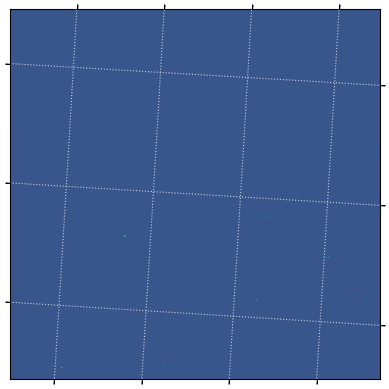

In [11]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
 
# Open the FITS file and retrieve the data
# and WCS header keyword information from the
# first science extension. Save the WCS
# information into an Astropy WCS object.
with fits.open(str(fpath)) as hdu:
    data = hdu[0].data
    wcs = WCS(hdu[0].header)
 
# Create the plotting object with the WCS projection.
plt.subplot(projection=wcs)
plt.imshow(data, )
plt.grid(color='white', ls=':', alpha=0.7)
plt.xticks()
plt.yticks()
plt.xlabel('Right Ascension')
plt.ylabel('Declination')
 
# Save the figure.
#plt.savefig('galaxies_wcs.png')

NameError: name 'yvu' is not defined

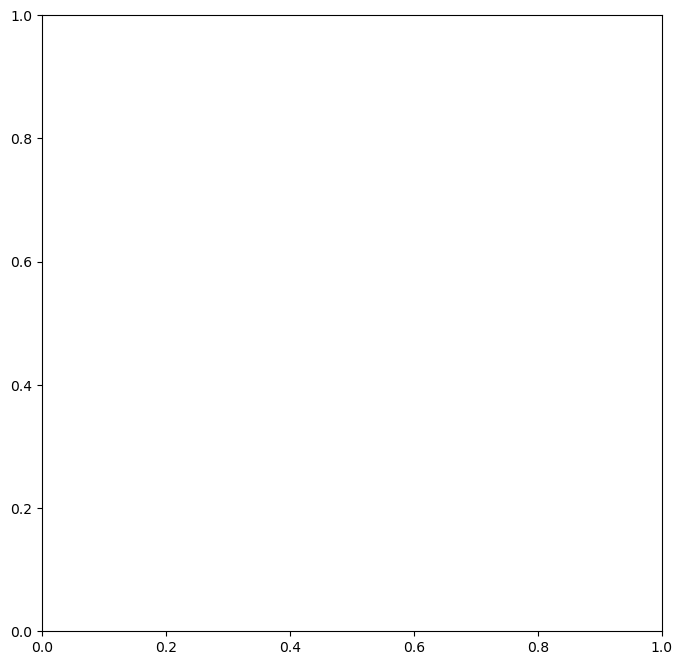

In [12]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt
 
# Open the FITS file and retrieve the data
# and WCS header keyword information from the
# first science extension. Save the WCS
# information into an Astropy WCS object.
with fits.open(str(fpath)) as hdu:
    data = hdu[0].data
    wcs = WCS(hdu[0].header)
 
# Select a subsection of the image to display.
# Here we have selected a 400 x 400 pixel section
# with x = [280:680] and y = [2290:2690].
cutout = data[2290:2690, 280:680]
 
# Create the plotting object with the WCS projection.
fig, axs = plt.subplots(1, 1, figsize=(8, 8), 
                        sharex=False, sharey=False, gridspec_kw=None)

im = yvu.zimshow(axs, 
                #hdul_dark0[0].data, 
                cutout,
                #vmax=vmax,
                #cmap='gray',
                origin = "upper"
                )

plt.grid(color='white', ls=':', alpha=0.7)
axs.set_xlabel('Right Ascension')
axs.set_ylabel('Declination')
 
# Save the figure.
#plt.savefig('galaxies_wcs.png')

str(fpath) /mnt/Rdata/CCD_obs/RiLA600_2022/BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/BARNARD174_Light_v_2022-10-18-15-28-21_030sec_RiLA600_STX-16803_-30C_1bin.fit
hdu.header['OBJCTRA'] 22 06 42
wcs WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 359.750350578  3.49405302978  
CRPIX : 2058.49534607  1867.65519714  
PC1_1 PC1_2  : -3.276875618074e-06  0.0001723419227257  
PC2_1 PC2_2  : -0.0001723728549693  -3.333550886382e-06  
CDELT : 1.0  1.0  
NAXIS : 4096  4096
7  Solved in 0.3 sec. Offset 8.4'. Mount offset RA=0.8', DEC=8.3'


/home/guitar79/anaconda3/envs/astro_Python_ubuntu_env/lib/python3.8/site-packages/astropy/wcs/wcs.py:3064: RuntimeWarning: cdelt will be ignored since cd is present
  description.append(s.format(*self.wcs.cdelt))


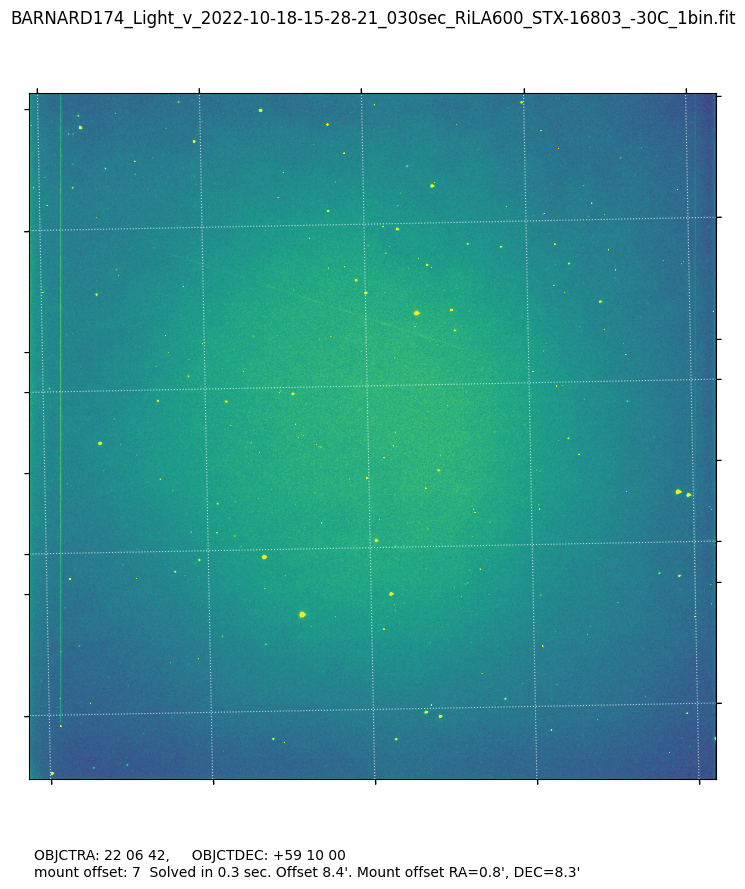

In [ ]:
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.io import fits
from astropy import units as u

print("str(fpath)", str(fpath))

hdu = fits.open(str(fpath))[0]
wcs = WCS(hdu.header)

print("hdu.header['OBJCTRA']", hdu.header['OBJCTRA'])
print("wcs", wcs)

mount_offset = ""
for comment in hdu.header['COMMENT']:
    if "Mount offset" in comment :
        print(comment)
        mount_offset = comment

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs, label='overlay')

im = yvu.zimshow(ax, hdu.data, 
        #vmin=-2.e-5, vmax=2.e-4, 
        origin='lower')

overlay = ax.get_coords_overlay('fk5')
#overlay = ax.get_coords_overlay('icrs')
overlay.grid(True, color='white', ls=':', alpha=0.7)
overlay[0].set_axislabel('Right Ascension (J2000)')
overlay[1].set_axislabel('Declination (J2000)')
#overlay[0].grid(color='red')
#overlay[1].grid(color='magenta')

#ax.set_title(f"{str(fpath.name)}")
plt.title(f"{str(fpath.name)}", pad=50)

fig = ax.get_figure()
fig.tight_layout()

plt.annotate(f"OBJCTRA: {hdu.header['OBJCTRA']}, \
    OBJCTDEC: {hdu.header['OBJCTDEC']}\nmount offset: {mount_offset}",
        fontsize=10, xy=(0, 0), xytext=(3, -50), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.show()


In [ ]:
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/BARNARD174_Light_v_2022-10-18-15-22-05_030sec_RiLA600_STX-16803_-30C_1bin.fit')
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/M27_Light_-_2022-10-12_-_RiLA600_STX-16803_-_1bin/solved/M27_Light_H_2022-10-12-13-28-39_400sec_RiLA600_STX-16803_-20C_1bin.fit')
#fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/M34_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/M34_Light_v_2022-10-18-12-46-35_090sec_RiLA600_STX-16803_-30C_1bin.fit')
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/MCG2-58-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/MCG2-58-5_Light_v_2022-10-18-15-15-07_030sec_RiLA600_STX-16803_-30C_1bin.fit')
#fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/BARNARD174_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/BARNARD174_Light_v_2022-10-18-15-24-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.io import fits
from astropy import units as u

print("str(fpath)", str(fpath))

hdu = fits.open(str(fpath))[0]
wcs = WCS(hdu.header)

print("hdu.header['OBJCTRA']", hdu.header['OBJCTRA'])
print("wcs", wcs)

mount_offset = ""
for comment in hdu.header['COMMENT']:
    if "Mount offset" in comment :
        print(comment)
        mount_offset = comment

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs, label='overlay')

im = yvu.zimshow(ax, hdu.data, 
        #vmin=-2.e-5, vmax=2.e-4, 
        origin='lower')

overlay = ax.get_coords_overlay('fk5')
#overlay = ax.get_coords_overlay('icrs')
overlay.grid(True, color='white', ls=':', alpha=0.7)
overlay[0].set_axislabel('Right Ascension (J2000)')
overlay[1].set_axislabel('Declination (J2000)')
#overlay[0].grid(color='red')
#overlay[1].grid(color='magenta')

#ax.set_title(f"{str(fpath.name)}")
plt.title(f"{str(fpath.name)}", pad=50)

fig = ax.get_figure()
fig.tight_layout()

plt.annotate(f"OBJCTRA: {hdu.header['OBJCTRA']}, \
    OBJCTDEC: {hdu.header['OBJCTDEC']}\nmount offset: {mount_offset}",
        fontsize=10, xy=(0, 0), xytext=(3, -50), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.show()

str(fpath) /mnt/Rdata/CCD_obs/RiLA600_2022/MCG2-58-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/MCG2-58-5_Light_v_2022-10-18-15-15-07_030sec_RiLA600_STX-16803_-30C_1bin.fit


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/Rdata/CCD_obs/RiLA600_2022/MCG2-58-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/MCG2-58-5_Light_v_2022-10-18-15-15-07_030sec_RiLA600_STX-16803_-30C_1bin.fit'

str(fpath) /mnt/Rdata/CCD_obs/RiLA600_2022/IC410_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC410_Light_H_2022-10-07-16-33-06_500sec_RiLA600_STX-16803_-19C_1bin.fit
hdu.header['OBJCTRA'] 05 16 26
wcs WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN-SIP'  'DEC--TAN-SIP'  
CRVAL : 78.9466382423  34.3647041165  
CRPIX : 2647.67172241  1311.15837479  
CD1_1 CD1_2  : -0.000172296100673  -1.68704459297e-06  
CD2_1 CD2_2  : 1.64351006806e-06  -0.000172421418976  
NAXIS : 4096  4096


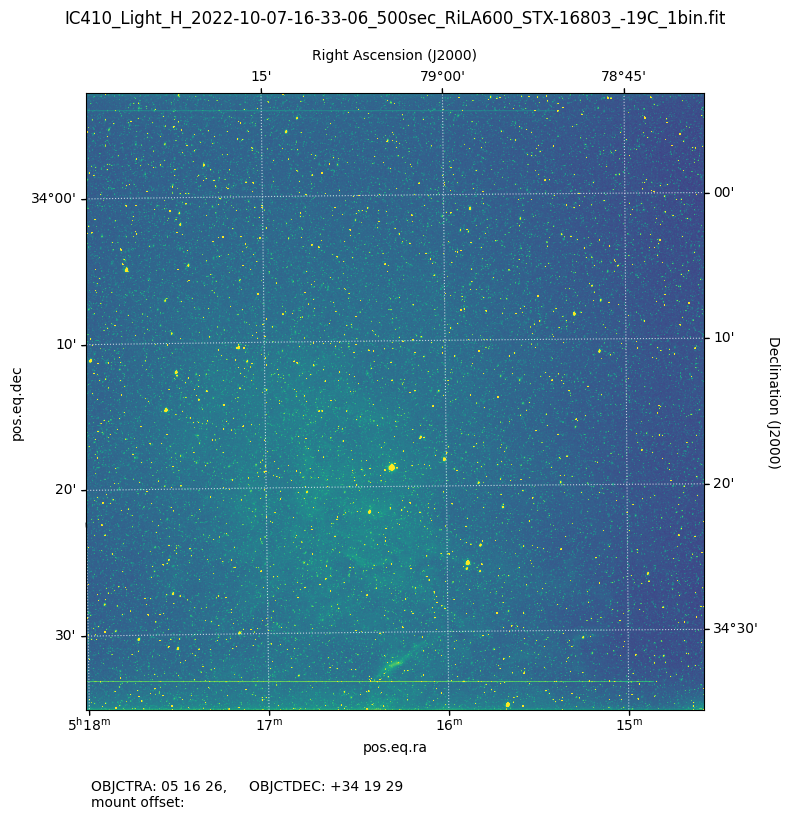

In [ ]:
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/IC410_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC410_Light_H_2022-10-07-16-33-06_500sec_RiLA600_STX-16803_-19C_1bin.fit')
#fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/ESO535-5_Light_v_2022-10-18-15-08-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
#fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/ESO535-5_Light_v_2022-10-18-15-08-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
#fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/IC405_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC405_Light_V_2022-10-07-14-13-53_080sec_RiLA600_STX-16803_-19C_1bin.fit')
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.io import fits
from astropy import units as u

print("str(fpath)", str(fpath))

hdu = fits.open(str(fpath))[0]
wcs = WCS(hdu.header)

print("hdu.header['OBJCTRA']", hdu.header['OBJCTRA'])
print("wcs", wcs)

mount_offset = ""
for comment in hdu.header['COMMENT']:
    if "Mount offset" in comment :
        print(comment)
        mount_offset = comment

fig = plt.figure(figsize=(8, 8))
ax = plt.subplot(projection=wcs, label='overlay')

im = yvu.zimshow(ax, hdu.data, 
        #vmin=-2.e-5, vmax=2.e-4, 
        origin='lower')

overlay = ax.get_coords_overlay('fk5')
#overlay = ax.get_coords_overlay('icrs')
overlay.grid(True, color='white', ls=':', alpha=0.7)
overlay[0].set_axislabel('Right Ascension (J2000)')
overlay[1].set_axislabel('Declination (J2000)')
#overlay[0].grid(color='red')
#overlay[1].grid(color='magenta')

#ax.set_title(f"{str(fpath.name)}")
plt.title(f"{str(fpath.name)}", pad=50)

fig = ax.get_figure()
fig.tight_layout()

plt.annotate(f"OBJCTRA: {hdu.header['OBJCTRA']}, \
    OBJCTDEC: {hdu.header['OBJCTDEC']}\nmount offset: {mount_offset}",
        fontsize=10, xy=(0, 0), xytext=(3, -50), va='top', ha='left',
        xycoords='axes fraction', textcoords='offset points')

plt.show()

In [ ]:
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/IC410_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC410_Light_H_2022-10-07-16-33-06_500sec_RiLA600_STX-16803_-19C_1bin.fit')
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/ESO535-5_Light_v_2022-10-18-15-08-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/ESO535-5_Light_-_2022-10-18_-_RiLA600_STX-16803_-_1bin/solved/ESO535-5_Light_v_2022-10-18-15-08-10_030sec_RiLA600_STX-16803_-30C_1bin.fit')
fpath = Path('/mnt/Rdata/CCD_obs/RiLA600_2022/IC405_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC405_Light_V_2022-10-07-14-13-53_080sec_RiLA600_STX-16803_-19C_1bin.fit')
import matplotlib.pyplot as plt

from astropy.wcs import WCS
from astropy.io import fits
from astropy import units as u

print("str(fpath)", str(fpath))

hdu = fits.open(str(fpath))[0]
wcs = WCS(hdu.header)

print(hdu.header)

str(fpath) /mnt/Rdata/CCD_obs/RiLA600_2022/IC405_Light_-_2022-10-07_-_RiLA600_STX-16803_-_1bin/solved/IC405_Light_V_2022-10-07-14-13-53_080sec_RiLA600_STX-16803_-19C_1bin.fit
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 4096                                                  NAXIS2  =                 4096                                                  DATE-OBS= '2022-10-07'         / ISO-8601 time of observation                   TIME-OBS= '14:13:53' /          HH:MM:SS observation start time, UT             EXPTIME =   80.000000000000000 /Exposure time in seconds                        EXPOSURE=   80.000000000000000 /Exposure time in seconds                        SET-TEMP=  -20.000000000000000 /CCD temperature setpoint in C                   CCD-TEMP=  -19.9687500000

In [ ]:
print(hdu.header)

SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                   16 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                 4096                                                  NAXIS2  =                 4096                                                  DATE-OBS= '2022-10-07'         / ISO-8601 time of observation                   TIME-OBS= '14:13:53' /          HH:MM:SS observation start time, UT             EXPTIME =   80.000000000000000 /Exposure time in seconds                        EXPOSURE=   80.000000000000000 /Exposure time in seconds                        SET-TEMP=  -20.000000000000000 /CCD temperature setpoint in C                   CCD-TEMP=  -19.968750000000000 /CCD temperature at start of exposure in C       XPIXSZ  =   9.0000000000000000 /Pixel Width in microns (after binning)          YPIXSZ  =   9.0000000000000000 /Pixel He